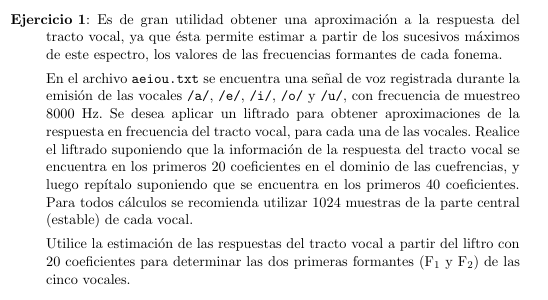

In [135]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import fft, fftfreq, ifft, fftshift
import csv

In [136]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

salida = cargar_dataset("PDS_Datos_TP2/aeiou_mas.txt")
salida /= max(salida)
#idx = np.arange(0, salida.shape[0], 5)
#salida = salida[idx]
N = len(salida)
#salida -= np.mean(salida)
print(salida.shape)

(36000,)


In [137]:
from scipy.io.wavfile import write

# cargar los datos (una columna de números)
#data = np.loadtxt("PDS_TP1_signals/hello.txt")

# normalizar si hace falta (ejemplo para float)
data = salida
data = data / np.max(np.abs(data))

# convertir a 16 bits
data_int16 = np.int16(data * 32767)

# guardar como WAV (ej: 44100 Hz)
write("PDS_Datos_TP2/audio_aeiou_mas.wav", 8000, data_int16)


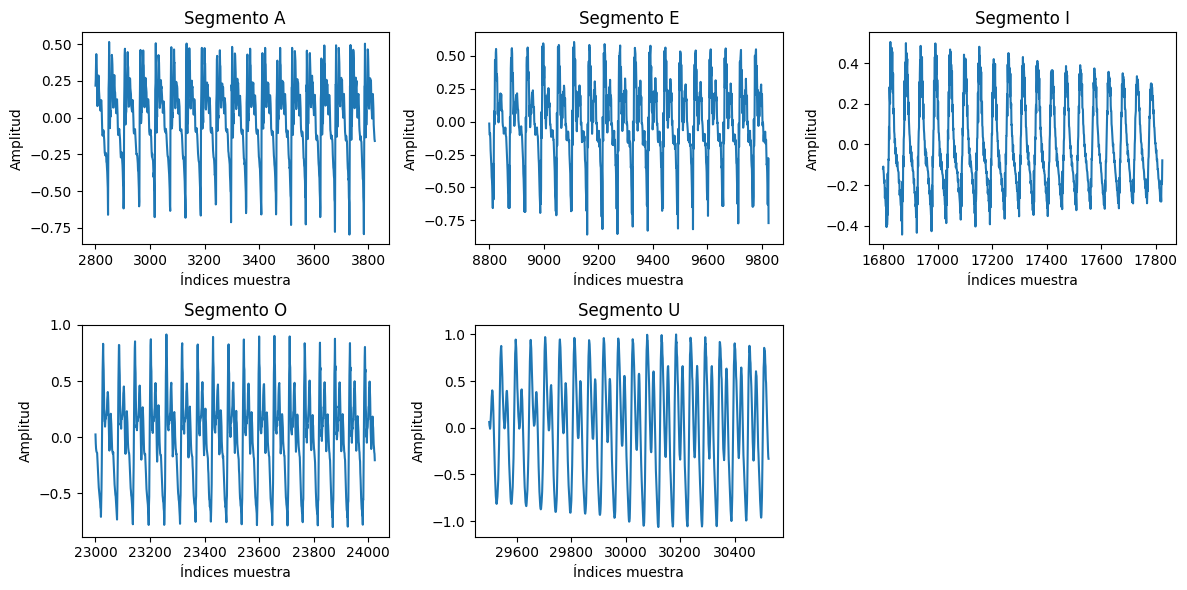

In [ ]:
#atras = 1000
#umbrales = [2800-atras, 8500-atras, 16500-atras, 23500-atras, 29750-atras]
#delante = 4700

umbrales = [2800, 8800, 16800, 23000, 29500]
delante = 1024

# SUMO 1 PQ EL RESTO DEL CODIGO LABURA CON DELANTE Y LO TENGO QUE DEJAR ASI

a = salida[umbrales[0] : umbrales[0]+delante+1]
e = salida[umbrales[1] : umbrales[1]+delante+1]
i = salida[umbrales[2] : umbrales[2]+delante+1]
o = salida[umbrales[3] : umbrales[3]+delante+1]
u = salida[umbrales[4] : umbrales[4]+delante+1]
nombres_vocales = ['A', 'E', 'I', 'O', 'U']
vocales = [a,e,i,o,u]

plt.figure(figsize=(12,6))
for i in range(len(vocales)):
    plt.subplot(2,3,i+1)
    plt.title(f"Segmento {nombres_vocales[i]}")
    plt.ylabel("Amplitud")
    plt.xlabel("Índices muestra")
    dom = np.arange(umbrales[i], umbrales[i]+delante+1, 1)
    plt.plot(dom, vocales[i])
plt.tight_layout()
plt.show()

a = 0.97
q = 0.001
for i in range(len(vocales)):
    # Remover la media
    vocales[i] -= np.mean(vocales[i])

    # Pre-énfasis
    vocales[i] = vocales[i][1:] - a * vocales[i][:-1]

    # PERTURBADO
    vocales[i] = vocales[i] + q * np.random.randn(len(vocales[i]))

    # Aplicar ventana
    ventana = np.hamming(len(vocales[i]))
    vocales[i] = vocales[i] * ventana
    vocales[i] /= np.max(np.abs(vocales[i]))

In [139]:
def extraer_coeficientes_cepstrales(vocal):
    v_tranf = fft(vocal)
    v_real = np.real(v_tranf)
    v_im = np.imag(v_tranf)
    v_norm = np.sqrt(v_real**2 + v_im**2)
    v_tranf = np.log(v_norm + 1e-10)
    v_inv = np.real(ifft(v_tranf))
    return np.array(v_inv)

1024


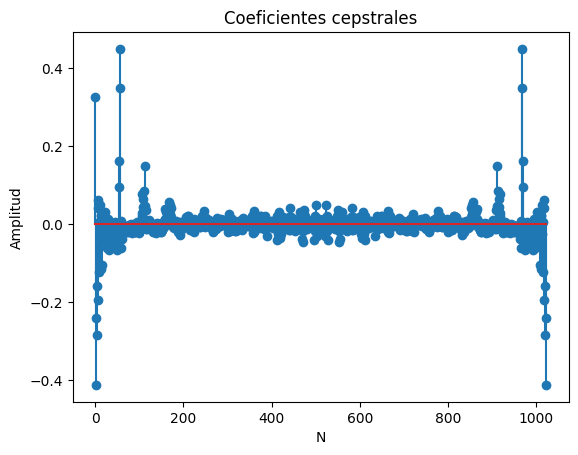

In [ ]:
coef = []
coef_filtrado = []
umbral = 20

print(len(vocales[2]))
for n in range(len(vocales)):
    datos = np.array(vocales[n])
    coeficientes = extraer_coeficientes_cepstrales(vocales[n])
    coef.append(coeficientes)
    filtrado = np.zeros_like(coeficientes)
    filtrado[: umbral] = coeficientes[: umbral] 
    filtrado[-umbral :] = coeficientes[-umbral :]
    coef_filtrado.append(filtrado)

coef = np.array(coef)
coef_filtrado = np.array(coef_filtrado)
plt.title("Coeficientes cepstrales")
plt.ylabel("Amplitud")
plt.xlabel("N")
plt.stem(coef[0])
plt.show()


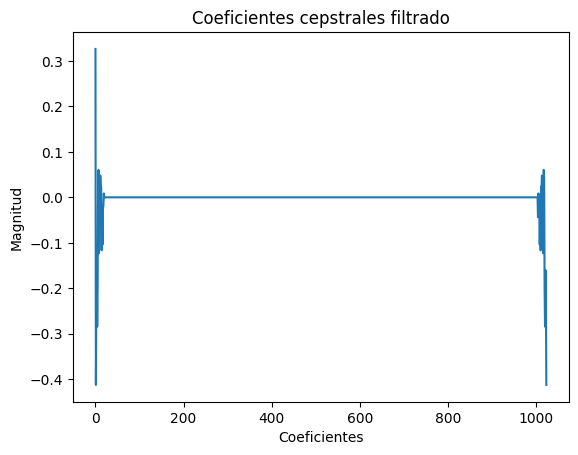

In [141]:
plt.title("Coeficientes cepstrales filtrado")
plt.plot(coef_filtrado[0])
plt.ylabel("Magnitud")
plt.xlabel("Coeficientes")
plt.show()

In [142]:
def señal_desde_coefs(coeficientes):
    fft_coef = fft(coeficientes)
    fft_exp = np.exp(fft_coef)
    return np.array(np.abs(fft_exp))

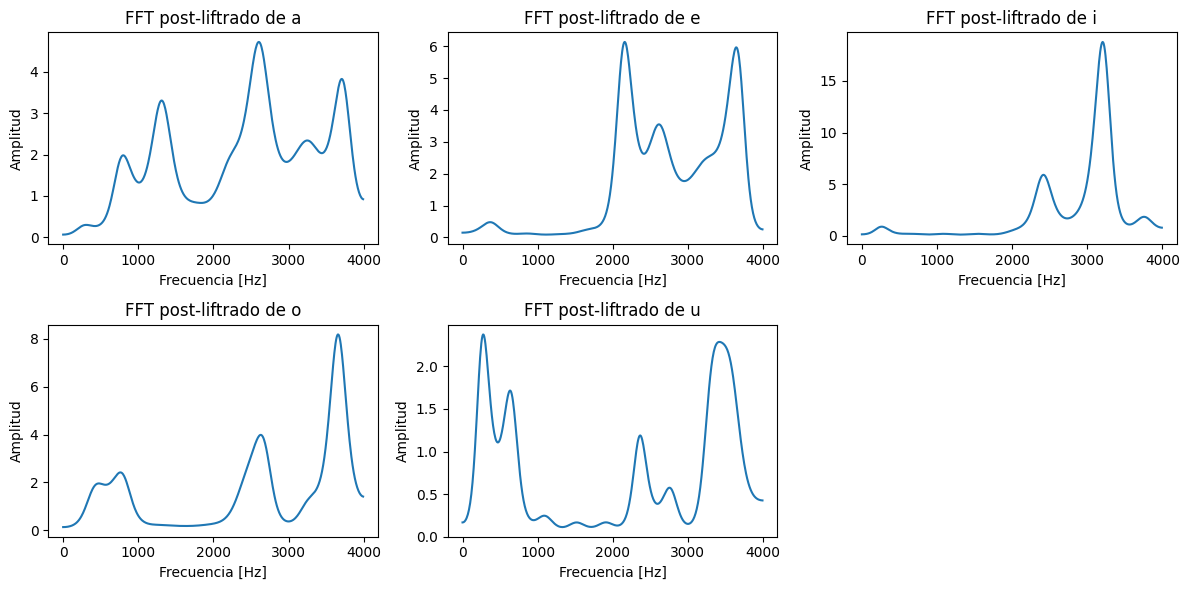

In [143]:
frecM = 8000
letras = ["a", "e", "i", "o", "u"]
ffts_post_liftrado = []

frecs = fftfreq(delante, d=1/frecM)  # eje de frecuencias
frecs = frecs[: len(frecs)//2]

plt.figure(figsize=(12,6))
for j in range(coef_filtrado.shape[0]):
    plt.subplot(2,3,j+1)
    frecu = señal_desde_coefs(coef_filtrado[j])
    ffts_post_liftrado.append(frecu[:len(frecu)//2])

    plt.title(f"FFT post-liftrado de {letras[j]}")
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Amplitud")
    plt.tight_layout()
    plt.plot(frecs,frecu[:len(frecu)//2])

plt.show()

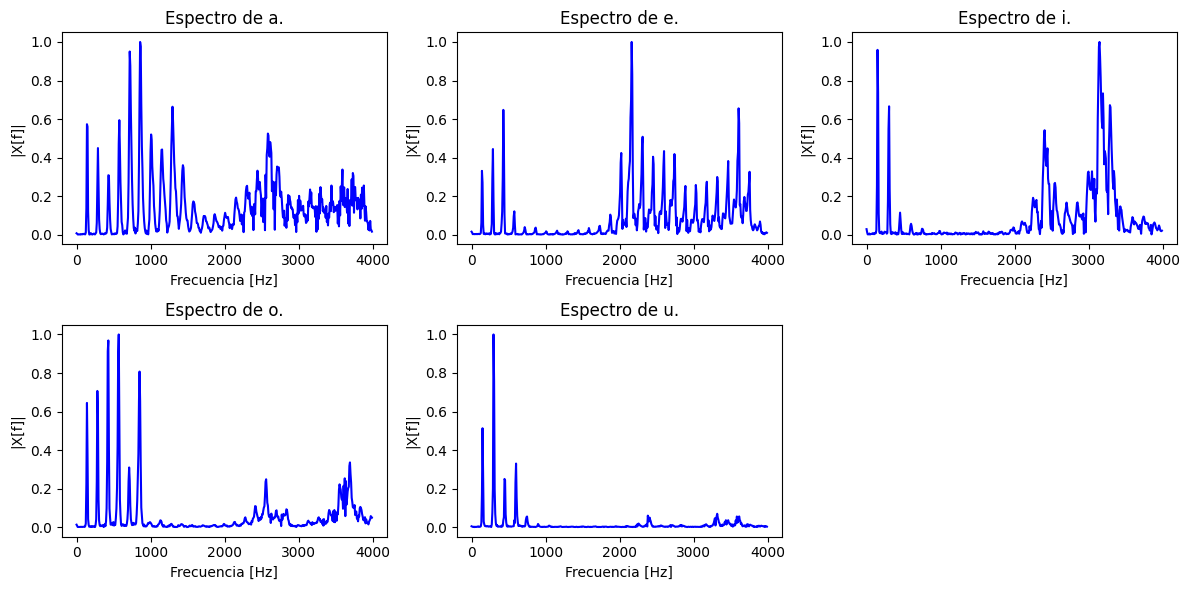

In [144]:

plt.figure(figsize=(12,6))
for j in range(len(vocales)):
    S = fft(vocales[j])
    # OBTENIENDO EL ESPECTRO DE LA SEÑAL
    S /= len(S)

    # Frecs
    S_real = np.real(S)
    S_im = np.imag(S)
    S_norm = np.sqrt(S_real**2 + S_im**2)
    S_norm = fftshift(S_norm)

    frecs = fftfreq(delante, d=1/frecM)  # eje de frecuencias
    frecs = fftshift(frecs)        # ordenar el eje: negativos a la izquierda

    y_xd = np.abs(S_norm)/max(np.abs(S_norm))
    # dominio de frecuencias
    plt.subplot(2,3,j+1)

    plt.plot(frecs[len(frecs)//2 :], y_xd[len(frecs)//2:], label="DFT de la señal", color="blue")
    plt.title(f"Espectro de {letras[j]}.")
    plt.tight_layout()
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|X[f]|")

plt.show()

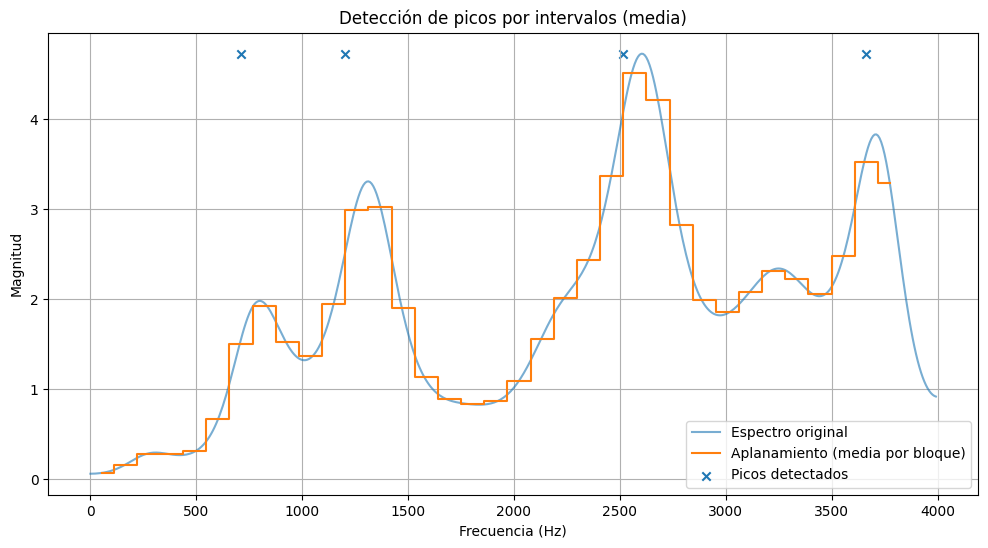

[ 710.9375 1203.125  2515.625  3664.0625]


In [145]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftfreq

def obtener_picos(senial, cant_intervalos=100, umbral=0, frecM=8000):    
    
    frecs = fftfreq(delante, d=1/frecM)
    frecs = frecs[: len(frecs)//2]

    N = len(senial)
    tam_intervalo = N // cant_intervalos

    frecuencias = []
    medias = []
    frecs_intervalos = []

    for i in range(cant_intervalos):
        inicio = i * tam_intervalo
        fin = inicio + tam_intervalo
        
        intervalo = senial[inicio:fin]
        
        if len(intervalo) > 0:
            media_val = np.mean(intervalo)
            medias.append(media_val)

            centro = (inicio + fin) // 2 

            if centro < len(frecs):
                freq = frecs[centro]
            else:
                freq = frecs[-1]

            frecuencias.append(freq)
            frecs_intervalos.append(freq)

    medias = np.array(medias)
    frecs_intervalos = np.array(frecs_intervalos)

    diferencias = np.diff(medias)

    i = 0
    frecs_fund = []

    while i < len(diferencias):
        if diferencias[i] > umbral:
            indices_racha = []

            # detectar racha consecutiva
            j = i
            while j < len(diferencias) and diferencias[j] > umbral:
                indices_racha.append(j)
                j += 1

            # tomar los dos últimos de la racha
            if len(indices_racha) >= 2:
                idx1 = indices_racha[-2] + 1
                idx2 = indices_racha[-1] + 1

                freq_media = (frecuencias[idx1] + frecuencias[idx2]) / 2
                frecs_fund.append(freq_media)

            else:
                # si solo hay uno, usar ese normalmente
                idx = indices_racha[0] + 1
                frecs_fund.append(frecuencias[idx])

            i = j
        else:
            i += 1

    frecs_fund = np.array(frecs_fund)

    # ------------------ PLOT ------------------

    plt.figure(figsize=(12,6))

    # señal original
    plt.plot(frecs[:len(senial)], senial, label="Espectro original", alpha=0.6)

    # aplanamiento
    plt.step(frecs_intervalos, medias, where='mid', label="Aplanamiento (media por bloque)")

    # picos detectados
    if len(frecs_fund) > 0:
        y_picos = [np.max(senial)] * len(frecs_fund)
        plt.scatter(frecs_fund, y_picos, marker='x', label="Picos detectados")

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title("Detección de picos por intervalos (media)")
    plt.legend()
    plt.grid()

    plt.show()

    return np.array(diferencias), frecs_fund

FRECS_FUND = []

diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[0], cant_intervalos=35, umbral=5e-1)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)


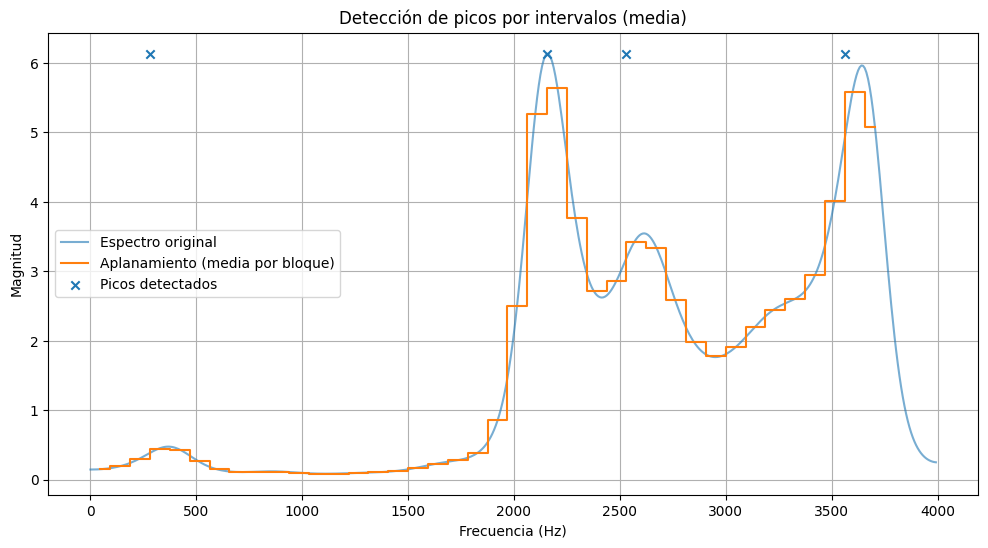

[ 281.25 2156.25 2531.25 3562.5 ]


In [146]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[1], cant_intervalos=40, umbral=2e-2)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

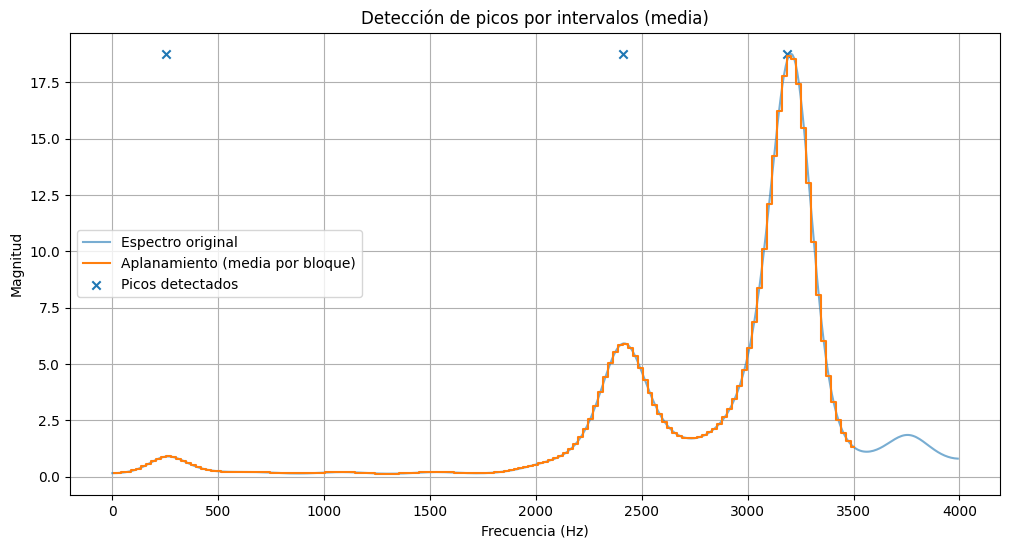

[ 253.90625 2410.15625 3183.59375]


In [147]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[2], cant_intervalos=150, umbral=2e-2)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

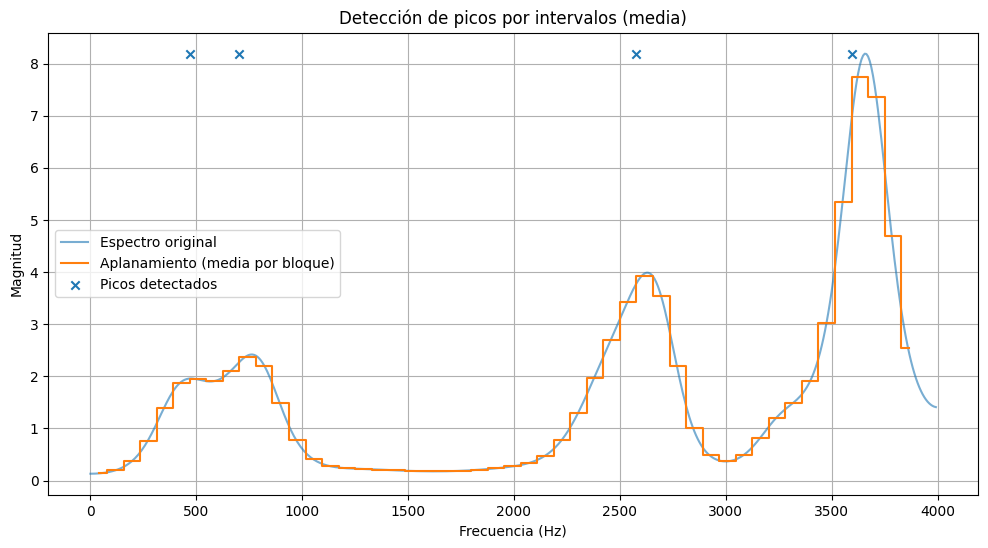

[ 468.75   703.125 2578.125 3593.75 ]


In [148]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[3], cant_intervalos=50, umbral=2.5e-4)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

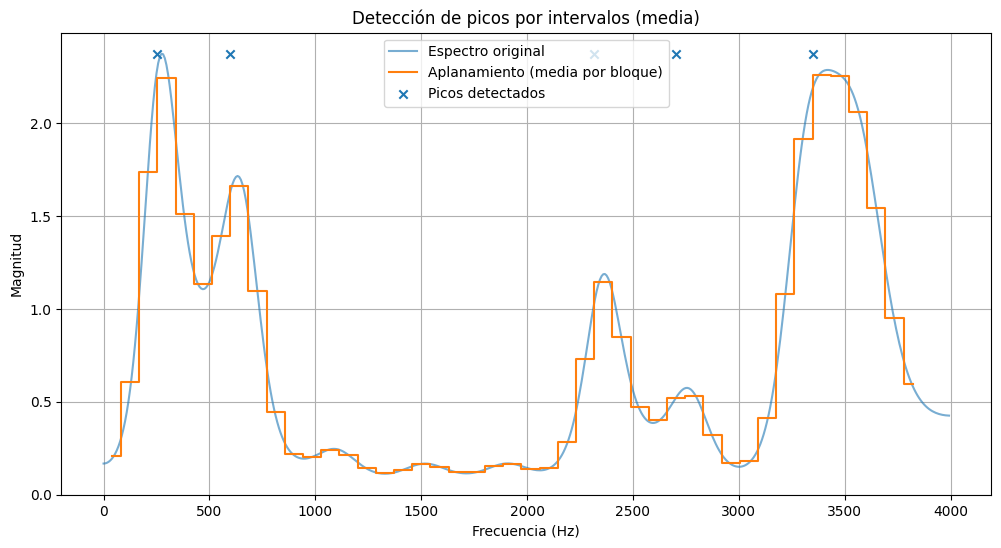

[ 253.90625  597.65625 2316.40625 2703.125   3347.65625]


In [149]:
diferencias, frecs_fund = obtener_picos(ffts_post_liftrado[4], cant_intervalos=45, umbral=5e-2)
FRECS_FUND.append(frecs_fund)
print(frecs_fund)

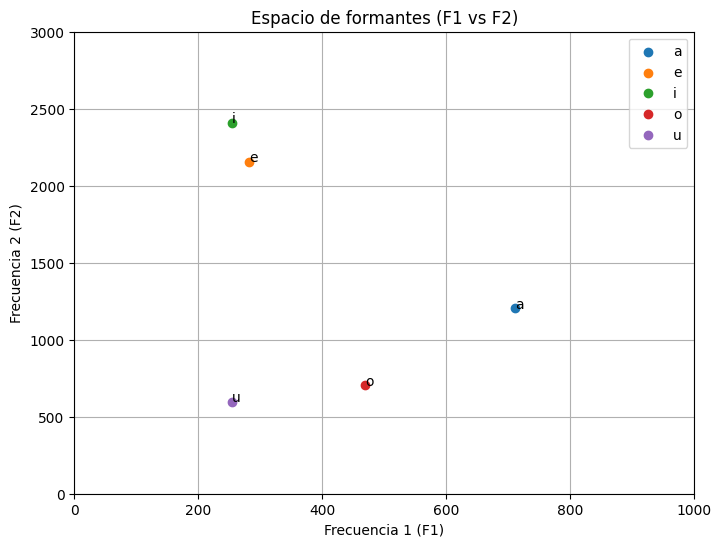

In [150]:
vocales = ['a', 'e', 'i', 'o', 'u']

plt.figure(figsize=(8,6))

for i, frecs in enumerate(FRECS_FUND):
    if len(frecs) >= 2:
        f1 = frecs[0] # EN FFT POST-LIFTRADO F1 ES EL PRIMER PICO
        f2 = frecs[1]

        plt.scatter(f1, f2, label=vocales[i])
        plt.text(f1, f2, vocales[i])  # etiqueta en el punto

plt.ylim(0,3000)
plt.xlim(0,1000)
plt.xlabel("Frecuencia 1 (F1)")
plt.ylabel("Frecuencia 2 (F2)")
plt.title("Espacio de formantes (F1 vs F2)")
plt.grid()
plt.legend()

plt.show()